In [ ]:
import os
import zipfile
import hashlib
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

zip_name = "archive.zip"
extract_path = "/content/soil_dataset"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/soil_dataset


In [ ]:
for root, folders, files in os.walk("/content/soil_dataset"):
    print(root)
    for file in files[:5]:
        print("   ", file)

/content/soil_dataset
/content/soil_dataset/test
/content/soil_dataset/test/Red soil
    Copy of image24.jpeg
    red-soil-background-6402446.jpg
    Copy of download (2).jpg
    Copy of annamalai-red-soil-suppliers-kotturpuram-chennai-red-soil-dealers-ey0ylh5r3e.jpg
    Nc-red-clay-soil-2.jpg
/content/soil_dataset/test/Clay soil
    Clay_13.jpg
    Clay_5.jpg
    Clay_3.jpg
    Clay_21.jpg
    Clay_17.jpg
/content/soil_dataset/test/Black Soil
    Black_22.jpg
    Black_30.jpg
    Black_6.jpg
    Black_23.jpg
    Black_32.jpg
/content/soil_dataset/test/Alluvial soil
    alluvial-soils-ricker-2primefarmland-crop-svf-x900.jpg
    Alluvial-Soil.jpg
    th4.jpg
    main-qimg-0d8bf61e156e099909ba8e8ae0d72383.png
    alluvial-soil.png
/content/soil_dataset/train_data
/content/soil_dataset/train_data/Clay Soil
    Copy of images43(1).jpg
    layers-earth-clay-pit-260nw-637609642.jpg
    arid-clay-soil-sun-desert-260nw-1672414813.jpg
    Copy of clay-soil2.jpg
    earthquake-vector-damage-crac

In [ ]:
from pathlib import Path

image_extensions = {
    ".jpg", ".jpeg", ".png",
    ".jfif", ".gif", ".bmp", ".webp"
}

image_files = []

for root, folders, files in os.walk("/content/soil_dataset"):
    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            image_files.append(os.path.join(root, file))

print("Total images:", len(image_files))

Total images: 529


In [ ]:
from collections import Counter
from pathlib import Path

class_counts = Counter()
split_counts = Counter()

for image_path in image_files:

    path_parts = Path(image_path).parts

    # Find train/test
    if "train_data" in [p.lower() for p in path_parts]:
        split = "Train"
    elif "test" in [p.lower() for p in path_parts]:
        split = "Test"
    else:
        split = "Unknown"

    split_counts[split] += 1

    # Find soil class from parent folder
    soil_class = Path(image_path).parent.name
    class_counts[soil_class] += 1

print("SOIL CLASS COUNTS")
print("------------------")

for soil_class, count in class_counts.items():
    print(soil_class, ":", count)

print("\nTRAIN / TEST")
print("------------")

for split, count in split_counts.items():
    print(split, ":", count)

SOIL CLASS COUNTS
------------------
Red soil : 44
Clay soil : 22
Black Soil : 162
Alluvial soil : 26
Clay Soil : 56
Alluvial Soil : 94
Red Soil : 125

TRAIN / TEST
------------
Test : 158
Train : 371


In [ ]:
from collections import Counter
from pathlib import Path

class_counts = Counter()

for image_path in image_files:

    folder_name = Path(image_path).parent.name

    # Normalize class names
    class_name = folder_name.strip().lower()

    if "red" in class_name:
        class_name = "Red Soil"

    elif "black" in class_name:
        class_name = "Black Soil"

    elif "alluvial" in class_name:
        class_name = "Alluvial Soil"

    elif "clay" in class_name:
        class_name = "Clay Soil"

    else:
        class_name = "Unknown"

    class_counts[class_name] += 1


print("FINAL SOIL CLASS COUNTS")
print("------------------------")

for soil_class, count in class_counts.items():
    print(soil_class, ":", count)

print("\nTOTAL:", sum(class_counts.values()))

FINAL SOIL CLASS COUNTS
------------------------
Red Soil : 169
Clay Soil : 78
Black Soil : 162
Alluvial Soil : 120

TOTAL: 529


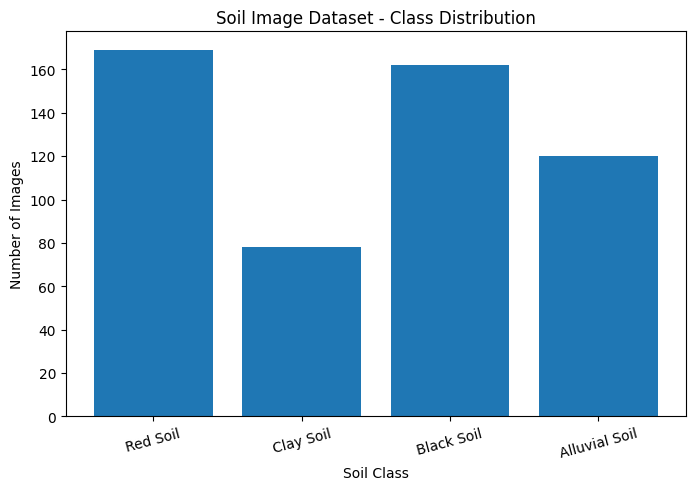

In [ ]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8,5))

plt.bar(classes, counts)

plt.title("Soil Image Dataset - Class Distribution")
plt.xlabel("Soil Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

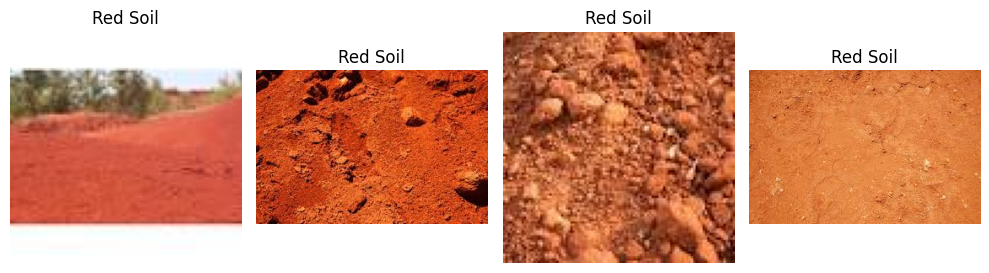

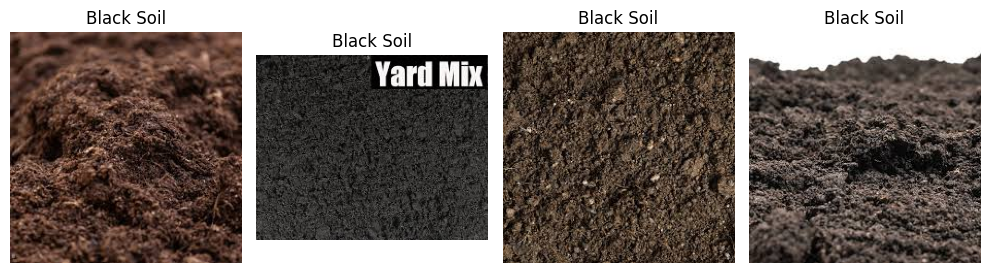

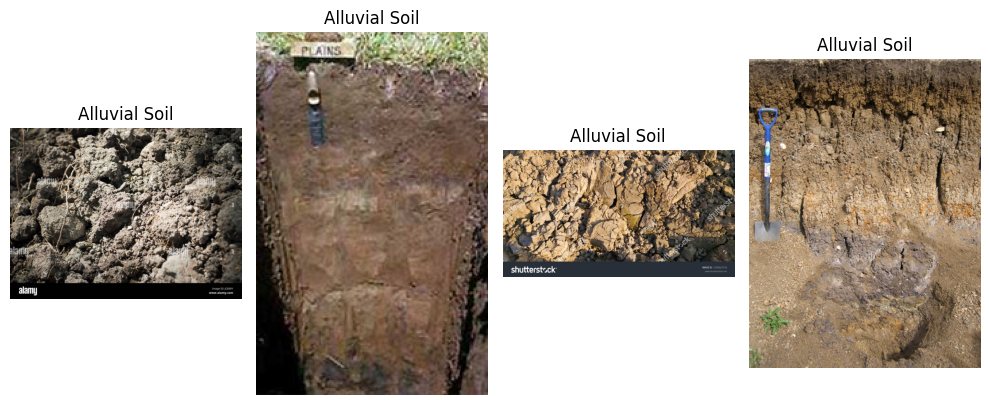

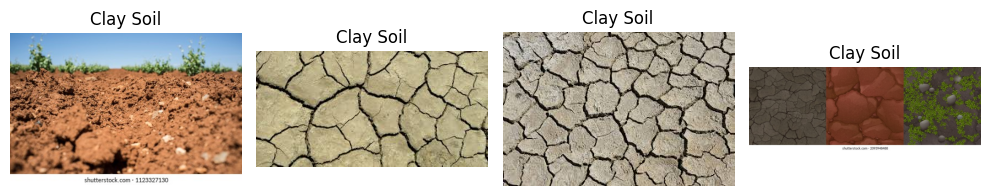

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

for selected_class in [
    "Red Soil",
    "Black Soil",
    "Alluvial Soil",
    "Clay Soil"
]:

    selected_images = []

    for image_path in image_files:

        folder_name = Path(image_path).parent.name.lower()

        if selected_class.lower().split()[0] in folder_name:
            selected_images.append(image_path)

    samples = random.sample(
        selected_images,
        min(4, len(selected_images))
    )

    plt.figure(figsize=(10,5))

    for i, image_path in enumerate(samples):

        img = Image.open(image_path)

        plt.subplot(1, len(samples), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(selected_class)

    plt.tight_layout()
    plt.show()

In [ ]:
from PIL import Image

corrupted_images = []

for image_path in image_files:

    try:
        img = Image.open(image_path)
        img.verify()

    except:
        corrupted_images.append(image_path)

print("Total corrupted images:", len(corrupted_images))

Total corrupted images: 0


In [ ]:
import hashlib

hashes = {}
duplicates = []

for image_path in image_files:

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    if file_hash in hashes:
        duplicates.append(image_path)

    else:
        hashes[file_hash] = image_path

print("Total duplicate images:", len(duplicates))

Total duplicate images: 48


In [ ]:
image_sizes = []

for image_path in image_files:

    try:
        img = Image.open(image_path)

        image_sizes.append({
            "File": Path(image_path).name,
            "Width": img.width,
            "Height": img.height,
            "Format": img.format
        })

    except:
        pass

image_size_df = pd.DataFrame(image_sizes)

image_size_df.head()

,File,Width,Height,Format
0,Copy of image24.jpeg,276,183,JPEG
1,red-soil-background-6402446.jpg,800,533,JPEG
2,Copy of download (2).jpg,259,194,JPEG
3,Copy of annamalai-red-soil-suppliers-kotturpur...,960,1280,JPEG
4,Nc-red-clay-soil-2.jpg,2560,1920,JPEG


In [ ]:
from google.colab import sheets
from google.colab import auth

auth.authenticate_user()
sheet = sheets.InteractiveSheet(df=image_size_df)

https://docs.google.com/spreadsheets/d/19CG7961rL5OiudomLUpAQbX8v0qbysiwi_i15JM5hyM/edit#gid=0


In [ ]:
image_size_df[["Width", "Height"]].describe()

,Width,Height
count,529.000000,529.000000
mean,415.941399,303.090737
std,330.453480,242.564899
min,100.000000,57.000000
25%,263.000000,183.000000
50%,318.000000,266.000000
75%,391.000000,280.000000
max,2592.000000,1920.000000


In [ ]:
import os
import shutil
import hashlib
from pathlib import Path

source_dir = "/content/soil_dataset"
clean_dir = "/content/clean_soil_dataset"

os.makedirs(clean_dir, exist_ok=True)

seen_hashes = set()

duplicates_removed = 0
unique_images = 0

for image_path in image_files:

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    if file_hash in seen_hashes:
        duplicates_removed += 1
        continue

    seen_hashes.add(file_hash)

    relative_path = os.path.relpath(
        image_path,
        source_dir
    )

    destination = os.path.join(
        clean_dir,
        relative_path
    )

    os.makedirs(
        os.path.dirname(destination),
        exist_ok=True
    )

    shutil.copy2(
        image_path,
        destination
    )

    unique_images += 1

print("Original images:", len(image_files))
print("Duplicate images removed:", duplicates_removed)
print("Unique images retained:", unique_images)

Original images: 529
Duplicate images removed: 48
Unique images retained: 481


In [ ]:
# Count images in the cleaned dataset

clean_images = []

for root, folders, files in os.walk(clean_dir):
    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            clean_images.append(os.path.join(root, file))

print("Cleaned dataset images:", len(clean_images))

Cleaned dataset images: 481


In [ ]:
from PIL import Image

corrupted_images = []

for image_path in clean_images:

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception:
        corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


In [ ]:
image_sizes = []

for image_path in clean_images:

    try:
        with Image.open(image_path) as img:
            image_sizes.append({
                "File": os.path.basename(image_path),
                "Width": img.width,
                "Height": img.height,
                "Format": img.format
            })

    except Exception:
        pass

image_df = pd.DataFrame(image_sizes)

print("Images successfully analyzed:", len(image_df))

image_df.head(10)

Images successfully analyzed: 481


,File,Width,Height,Format
0,Copy of image24.jpeg,276,183,JPEG
1,red-soil-background-6402446.jpg,800,533,JPEG
2,Copy of download (2).jpg,259,194,JPEG
3,Copy of annamalai-red-soil-suppliers-kotturpur...,960,1280,JPEG
4,Nc-red-clay-soil-2.jpg,2560,1920,JPEG
5,Copy of images104.jpg,275,183,JPEG
6,Copy of image25.jpeg,265,190,JPEG
7,images188.jpg,100,100,JPEG
8,Red-soil-essay.jpg,640,480,JPEG
9,Copy of images131.jpg,276,183,JPEG


In [ ]:
import os
import shutil
from PIL import Image

processed_dir = "/content/processed_soil_dataset"

# Remove old processed folder if it already exists
if os.path.exists(processed_dir):
    shutil.rmtree(processed_dir)

os.makedirs(processed_dir, exist_ok=True)

print("Processed dataset folder created!")

Processed dataset folder created!


In [ ]:
IMG_SIZE = (224, 224)

processed_images = 0
failed_images = []

for image_path in clean_images:

    try:
        # Keep the same folder structure
        relative_path = os.path.relpath(
            image_path,
            clean_dir
        )

        destination_path = os.path.join(
            processed_dir,
            relative_path
        )

        # Create destination folders
        os.makedirs(
            os.path.dirname(destination_path),
            exist_ok=True
        )

        # Open and resize image
        with Image.open(image_path) as img:

            # Convert image to RGB
            img = img.convert("RGB")

            # Resize image
            img = img.resize(
                IMG_SIZE
            )

            # Save resized image
            img.save(
                destination_path,
                quality=95
            )

        processed_images += 1

    except Exception as e:

        failed_images.append(image_path)


print("Images resized successfully:", processed_images)
print("Failed images:", len(failed_images))

Images resized successfully: 481
Failed images: 0


In [ ]:
from pathlib import Path

resized_images = []

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

for root, folders, files in os.walk(processed_dir):

    for file in files:

        if file.lower().endswith(image_extensions):

            resized_images.append(
                os.path.join(root, file)
            )

print("Total resized images:", len(resized_images))

Total resized images: 455


In [ ]:
from collections import Counter

image_dimensions = []

for image_path in resized_images:

    try:
        with Image.open(image_path) as img:
            image_dimensions.append(img.size)

    except Exception:
        pass


dimension_counts = Counter(image_dimensions)

print("IMAGE DIMENSIONS")
print("================")

for dimension, count in dimension_counts.items():
    print(dimension, ":", count)

IMAGE DIMENSIONS
(224, 224) : 455


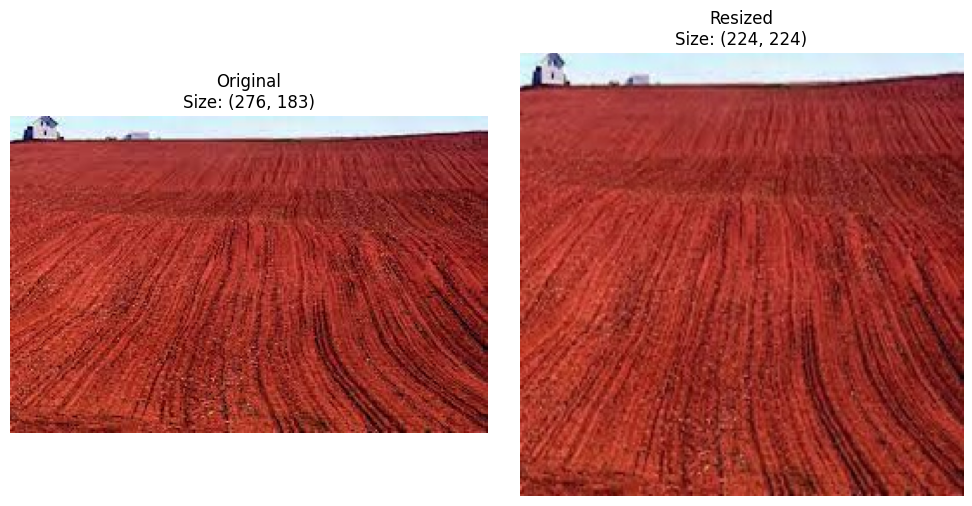

In [ ]:
import matplotlib.pyplot as plt

original_image = clean_images[0]

relative_path = os.path.relpath(
    original_image,
    clean_dir
)

processed_image = os.path.join(
    processed_dir,
    relative_path
)

original = Image.open(original_image)
resized = Image.open(processed_image)

plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)

plt.imshow(original)

plt.title(
    f"Original\nSize: {original.size}"
)

plt.axis("off")


# Resized image
plt.subplot(1, 2, 2)

plt.imshow(resized)

plt.title(
    f"Resized\nSize: {resized.size}"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

print("Normalization layer created successfully!")
print("Pixel values: 0–255 → 0–1")

Normalization layer created successfully!
Pixel values: 0–255 → 0–1


In [ ]:
from PIL import Image
import numpy as np

test_image_path = resized_images[0]

img = Image.open(test_image_path).convert("RGB")

img_array = np.array(img)

print("Before normalization:")
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

# Convert to TensorFlow tensor
img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

# Normalize
normalized_image = normalization_layer(img_tensor)

print("\nAfter normalization:")
print("Minimum pixel value:", tf.reduce_min(normalized_image).numpy())
print("Maximum pixel value:", tf.reduce_max(normalized_image).numpy())

Before normalization:
Minimum pixel value: 0
Maximum pixel value: 255

After normalization:
Minimum pixel value: 0.0
Maximum pixel value: 1.0


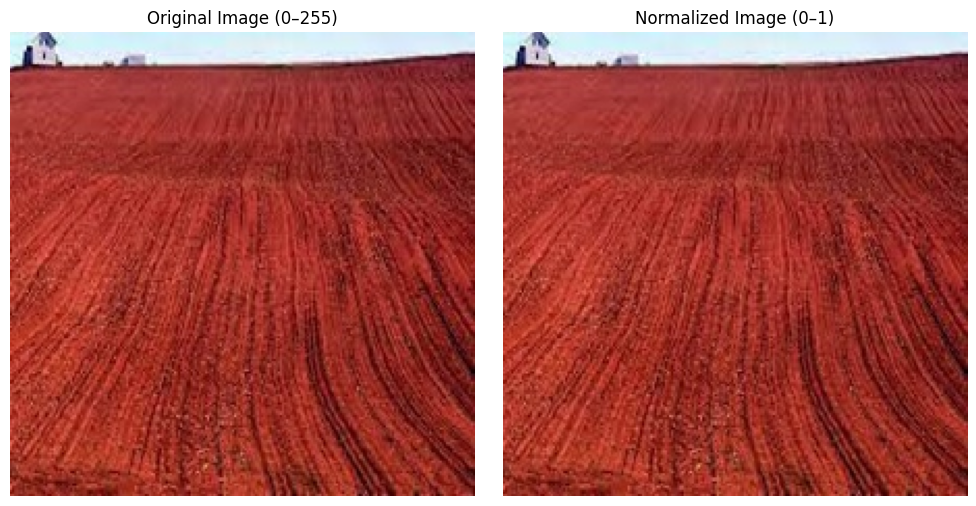

In [ ]:
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(img_array.astype("uint8"))
plt.title("Original Image (0–255)")
plt.axis("off")

# Normalized
plt.subplot(1, 2, 2)
plt.imshow(normalized_image.numpy())
plt.title("Normalized Image (0–1)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

print("Normalization layer created successfully!")
print("Pixel values will be converted from 0–255 to 0–1")

Normalization layer created successfully!
Pixel values will be converted from 0–255 to 0–1


In [ ]:
test_image_path = resized_images[0]

img = Image.open(test_image_path).convert("RGB")

img_array = np.array(img)

print("Before normalization:")
print("Minimum:", img_array.min())
print("Maximum:", img_array.max())

img_tensor = tf.convert_to_tensor(
    img_array,
    dtype=tf.float32
)

normalized_image = normalization_layer(img_tensor)

print("\nAfter normalization:")
print("Minimum:", tf.reduce_min(normalized_image).numpy())
print("Maximum:", tf.reduce_max(normalized_image).numpy())

Before normalization:
Minimum: 0
Maximum: 255

After normalization:
Minimum: 0.0
Maximum: 1.0


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Augmentation pipeline created successfully!")

Augmentation pipeline created successfully!


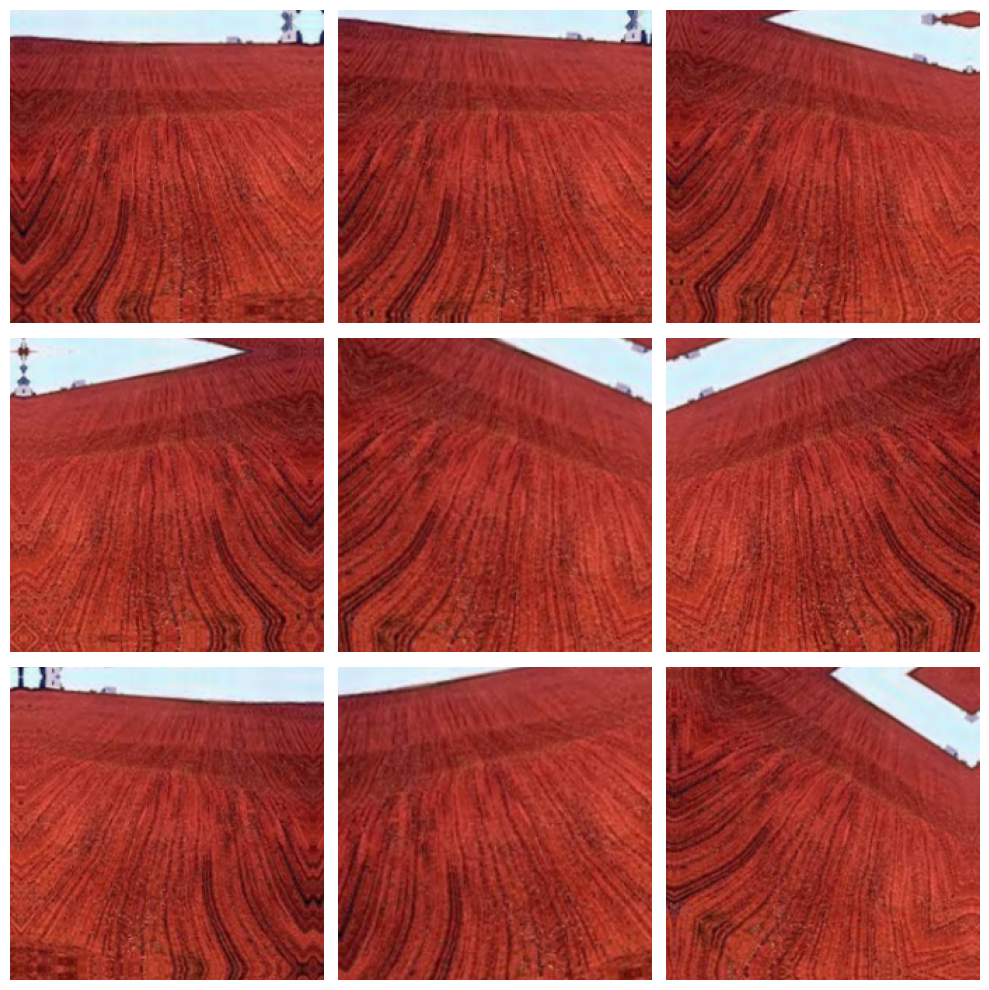

In [ ]:
sample_image_path = resized_images[0]

img = tf.keras.utils.load_img(
    sample_image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0)

plt.figure(figsize=(10, 10))

for i in range(9):

    augmented_image = data_augmentation(img_array)

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        augmented_image[0].numpy().astype("uint8")
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

from pathlib import Path
from sklearn.model_selection import train_test_split

In [ ]:
train_files = []

for image_path in resized_images:

    path_parts = [
        part.lower()
        for part in Path(image_path).parts
    ]

    if "train_data" in path_parts:

        train_files.append(image_path)

print("Original training images:", len(train_files))

Original training images: 312


In [ ]:
labels = []

for image_path in train_files:

    class_name = Path(
        image_path
    ).parent.name

    labels.append(class_name)

print("Classes found:")
print(sorted(set(labels)))

Classes found:
['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']


In [ ]:
train_split, validation_split = train_test_split(

    train_files,

    test_size=0.20,

    random_state=42,

    stratify=labels
)

print("Training images:", len(train_split))
print("Validation images:", len(validation_split))

Training images: 249
Validation images: 63


In [ ]:
final_dataset_dir = "/content/final_soil_dataset"

if os.path.exists(final_dataset_dir):

    shutil.rmtree(final_dataset_dir)

os.makedirs(
    final_dataset_dir,
    exist_ok=True
)

print("Final dataset folder created!")

Final dataset folder created!


In [ ]:
def copy_images(image_list, split_name):

    for image_path in image_list:

        class_name = Path(
            image_path
        ).parent.name

        destination_folder = os.path.join(

            final_dataset_dir,

            split_name,

            class_name
        )

        os.makedirs(

            destination_folder,

            exist_ok=True
        )

        destination_path = os.path.join(

            destination_folder,

            Path(image_path).name
        )

        shutil.copy2(

            image_path,

            destination_path
        )

In [ ]:
copy_images(
    train_split,
    "train"
)

print("Training dataset copied!")

Training dataset copied!


In [ ]:
copy_images(
    validation_split,
    "validation"
)

print("Validation dataset copied!")

Validation dataset copied!


In [ ]:
test_files = []

for image_path in resized_images:

    path_parts = [

        part.lower()

        for part in Path(image_path).parts

    ]

    if "test" in path_parts:

        test_files.append(
            image_path
        )

print("Test images:", len(test_files))

Test images: 143


In [ ]:
copy_images(
    test_files,
    "test"
)

print("Test dataset copied!")

Test dataset copied!


In [ ]:
final_counts = {}

splits = [

    "train",

    "validation",

    "test"
]

for split in splits:

    split_path = os.path.join(

        final_dataset_dir,

        split
    )

    count = 0

    for root, folders, files in os.walk(split_path):

        for file in files:

            if file.lower().endswith(

                (
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".webp"
                )

            ):

                count += 1

    final_counts[split] = count


print("FINAL DATASET COUNTS")
print("====================")

for split, count in final_counts.items():

    print(

        split.upper(),

        ":",

        count
    )

FINAL DATASET COUNTS
TRAIN : 249
VALIDATION : 63
TEST : 143


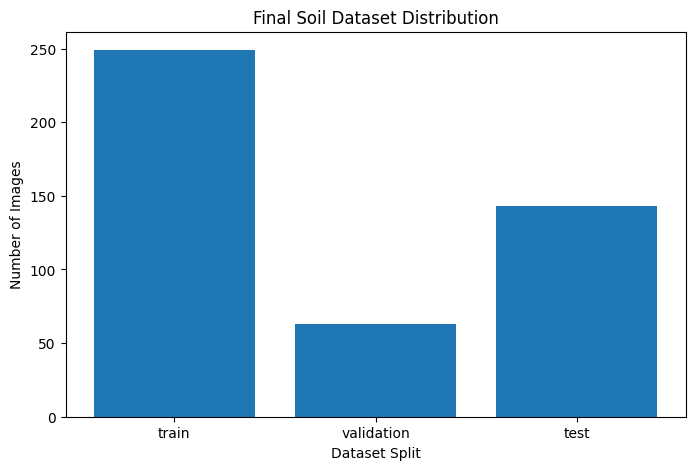

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(

    list(final_counts.keys()),

    list(final_counts.values())

)

plt.title(
    "Final Soil Dataset Distribution"
)

plt.xlabel(
    "Dataset Split"
)

plt.ylabel(
    "Number of Images"
)

plt.show()

In [ ]:
from collections import Counter

for split in splits:

    split_path = os.path.join(

        final_dataset_dir,

        split
    )

    class_counts = Counter()

    for root, folders, files in os.walk(split_path):

        for file in files:

            if file.lower().endswith(

                (
                    ".jpg",
                    ".jpeg",
                    ".png"
                )

            ):

                class_name = Path(
                    root
                ).name

                class_counts[class_name] += 1


    print("\n", split.upper())

    print("----------------")

    for class_name, count in class_counts.items():

        print(

            class_name,

            ":",

            count
        )


 TRAIN
----------------
Clay Soil : 33
Black Soil : 61
Alluvial Soil : 73
Red Soil : 82

 VALIDATION
----------------
Clay Soil : 8
Black Soil : 15
Alluvial Soil : 19
Red Soil : 21

 TEST
----------------
Red soil : 43
Clay soil : 22
Black Soil : 53
Alluvial soil : 25


In [ ]:
import shutil
from google.colab import files

# Create one ZIP containing the final dataset
shutil.make_archive(
    "/content/soil_project_output",
    "zip",
    "/content",
    "final_soil_dataset"
)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
files.download("/content/soil_project_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/final_soil_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/final_soil_dataset/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/final_soil_dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 249 files belonging to 4 classes.
Found 63 files belonging to 4 classes.
Found 143 files belonging to 4 classes.
Classes: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']


In [ ]:

# EfficientNetB0 Transfer Learning

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Number of soil classes
NUM_CLASSES = len(train_ds.class_names)

print("Classes:", train_ds.class_names)
print("Number of classes:", NUM_CLASSES)

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# EfficientNetB0
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

# Display model
model.summary()

Classes: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']
Number of classes: 4


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
#IMPORT LIBRARIES


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


In [ ]:
#CHECK DATASET

print("Classes:", train_ds.class_names)
print("Number of classes:", len(train_ds.class_names))

print("\nTraining batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Classes: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']
Number of classes: 4

Training batches: 16
Validation batches: 4
Testing batches: 9


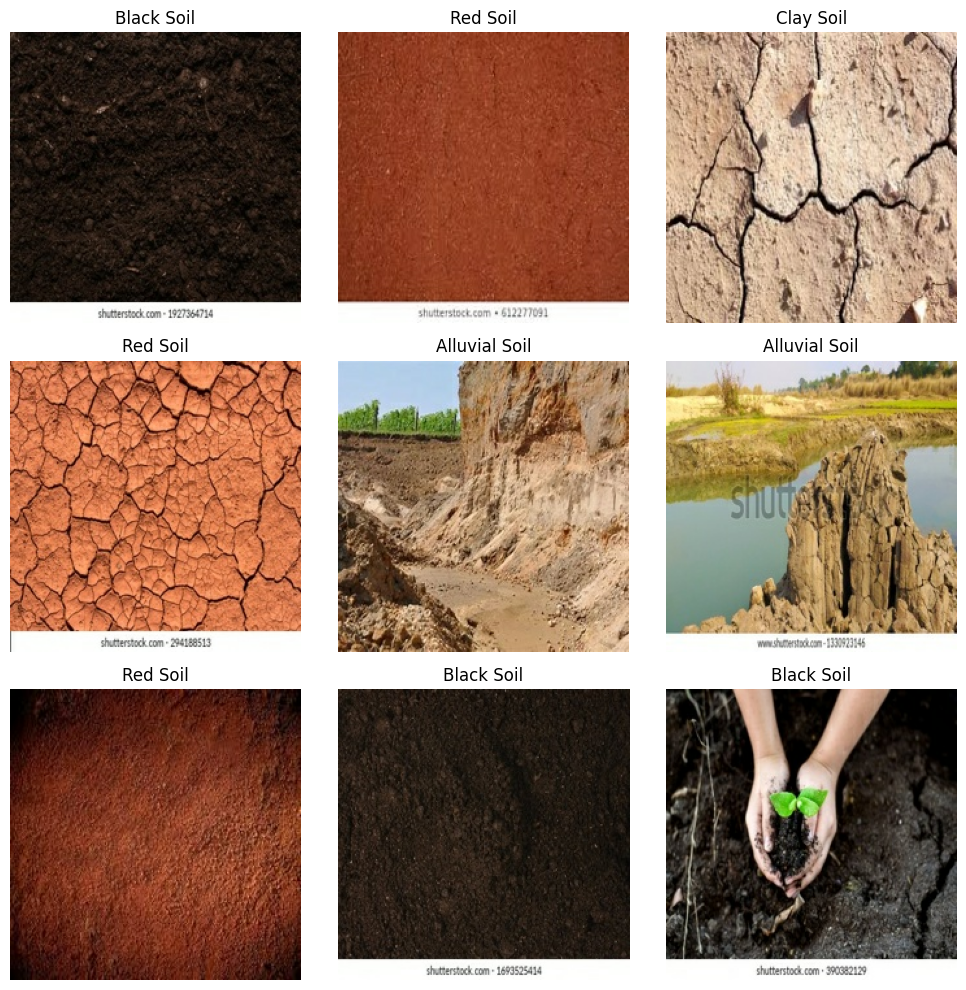

In [ ]:

#DISPLAY TRAINING IMAGES

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_ds.class_names[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#LOAD EFFICIENTNETB0


IMG_SIZE = (224, 224)
NUM_CLASSES = len(train_ds.class_names)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

print("EfficientNetB0 loaded successfully!")
print("Pretrained layers frozen.")

EfficientNetB0 loaded successfully!
Pretrained layers frozen.


In [ ]:

#BUILD CNN MODEL


inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

# Data augmentation
x = data_augmentation(inputs)

# Pretrained EfficientNet
x = base_model(
    x,
    training=False
)

# Convert feature maps into one feature vector
x = layers.GlobalAveragePooling2D()(x)

# Prevent overfitting
x = layers.Dropout(0.3)(x)

# Custom classification layer
x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.2)(x)

# Final 4-class prediction
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:

#TRAINING CALLBACKS


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/best_soil_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
#TRAIN CNN


EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8474 - loss: 0.4581 - val_accuracy: 0.8254 - val_loss: 0.5460 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8835 - loss: 0.3782 - val_accuracy: 0.8254 - val_loss: 0.5097 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8675 - loss: 0.3210 - val_accuracy: 0.8095 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8795 - loss: 0.3435 - val_accuracy: 0.8254 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9036 - loss: 0.2779 - val_accuracy: 0.8413 - val_loss: 0.5068 - learning_rate: 5.0000e-04
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9197 - loss: 0.2449 - val_accuracy: 0.8413 - val_loss: 0.5085 - learning_rate: 5.0000e-04
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9317 - loss: 0.1989 - val_ac

In [ ]:

#ACCURACY GRAPH


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:

#LOSS GRAPH


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:

#TEST EVALUATION


test_loss, test_accuracy = model.evaluate(
    test_ds
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:

#GENERATE PREDICTIONS


y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated!")
print("Number of test samples:", len(y_true))

In [ ]:

#PRECISION, RECALL, F1


report = classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names,
    digits=4
)

print(report)

In [ ]:

# CONFUSION MATRIX


cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_ds.class_names
)

disp.plot(
    values_format="d"
)

plt.title("Soil Classification Confusion Matrix")
plt.xticks(rotation=20)

plt.show()

In [ ]:

#FIND INCORRECT PREDICTIONS


wrong_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Incorrect predictions:",
    len(wrong_indices)
)

print(
    "Correct predictions:",
    len(y_true) - len(wrong_indices)
)

In [ ]:

# DISPLAY WRONG PREDICTIONS


all_test_images = []
all_test_labels = []

for images, labels in test_ds:

    all_test_images.extend(
        images.numpy()
    )

    all_test_labels.extend(
        labels.numpy()
    )

all_test_images = np.array(all_test_images)
all_test_labels = np.array(all_test_labels)

num_to_show = min(
    12,
    len(wrong_indices)
)

plt.figure(figsize=(12, 9))

for i in range(num_to_show):

    index = wrong_indices[i]

    image = all_test_images[index]

    actual = train_ds.class_names[
        y_true[index]
    ]

    predicted = train_ds.class_names[
        y_pred[index]
    ]

    ax = plt.subplot(3, 4, i + 1)

    plt.imshow(
        image.astype("uint8")
    )

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

#SAVE MODEL


model.save(
    "/content/soil_cnn_final.keras"
)

print("Model saved successfully!")
print("/content/soil_cnn_final.keras")

In [ ]:

#  LOAD SAVED MODEL


loaded_model = tf.keras.models.load_model(
    "/content/soil_cnn_final.keras"
)

print("Saved model loaded successfully!")

loaded_loss, loaded_accuracy = loaded_model.evaluate(
    test_ds,
    verbose=0
)

print("Loaded model test accuracy:", loaded_accuracy)

In [ ]:

#SAVE CLASS NAMES


import json

class_mapping = {
    str(i): class_name
    for i, class_name in enumerate(
        train_ds.class_names
    )
}

with open(
    "/content/soil_class_names.json",
    "w"
) as f:

    json.dump(
        class_mapping,
        f,
        indent=4
    )

print("Class mapping:")
print(class_mapping)

print("\nClass names saved!")

In [ ]:

#SAVE EVALUATION REPORT


with open(
    "/content/soil_cnn_evaluation_report.txt",
    "w"
) as f:

    f.write(
        "SOIL CNN EVALUATION REPORT\n"
    )

    f.write(
        "==========================\n\n"
    )

    f.write(
        f"Test Accuracy: {test_accuracy:.4f}\n"
    )

    f.write(
        f"Test Loss: {test_loss:.4f}\n\n"
    )

    f.write(
        "Classification Report:\n"
    )

    f.write(report)

print(
    "Evaluation report saved successfully!"
)

In [ ]:

# CREATE OUTPUT ZIP


import shutil

output_files = [
    "/content/soil_cnn_final.keras",
    "/content/best_soil_model.keras",
    "/content/soil_class_names.json",
    "/content/soil_cnn_evaluation_report.txt"
]

existing_files = [
    file for file in output_files
    if os.path.exists(file)
]

print("Files ready:")
for file in existing_files:
    print(file)

shutil.make_archive(
    "/content/soil_cnn_week3_output",
    "zip",
    "/content",
    base_dir=None
)

KeyboardInterrupt: 

In [ ]:

# CREATE CLEAN OUTPUT FOLDER


output_dir = "/content/soil_cnn_output"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(output_dir)

for file in existing_files:
    shutil.copy2(
        file,
        output_dir
    )

shutil.make_archive(
    "/content/soil_cnn_week3_output",
    "zip",
    output_dir
)

print("Week 3 output ZIP created!")

In [ ]:
from google.colab import files

files.download(
    "/content/soil_cnn_week3_output.zip"
)